# Практическая работа 2 Обучение с учителем

## Часть 1 Подготовка датасета

### Подключение библиотек

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
#LabelEncoder нужен, чтобы превращать текстовые столбцы 
#(Type, Color, Material) в числа, потому что 
#модель не понимает слова
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import seaborn as sns
%matplotlib inline

### Загрузка датасета

In [2]:
df = pd.read_csv('21 fridges.csv')

### Обработка датасета

In [3]:
# УДАЛЯЕМ указанные поля: Model, Random Numeric Feature 1, Random Text Feature 2, Irrelevant Category Feature 3
df = df.drop(['Model', 'Random Numeric Feature 1', 'Random Text Feature 2', 'Irrelevant Category Feature 3'], axis=1)

# Удаление пустых строк
df = df.dropna()

# ========== ПРАВИЛЬНАЯ ОБРАБОТКА ПРИЗНАКОВ ДЛЯ ХОЛОДИЛЬНИКОВ ==========

# 1. Energy Rating (A++ > A+ > A > B)
energy_map = {'A++': 4, 'A+': 3, 'A': 2, 'B': 1}
df['Energy Rating'] = df['Energy Rating'].map(energy_map).fillna(0).astype(int)

# 2. Type (Side-by-Side > Double Door > Single Door > None)
type_map = {'Side-by-Side': 3, 'Double Door': 2, 'Single Door': 1, 'None': 0}
df['Type'] = df['Type'].map(type_map).fillna(0).astype(int)

# 3. Brand – заменяем текст на числа
df['Brand'] = df['Brand'].str.strip()
brands = {
    'Panasonic': 0,
    'GE': 1,
    'LG': 2,
    'Bosch': 3,
    'Siemens': 4,
    'Samsung': 5,
    'Haier': 6,
    'Frigidaire': 7,
    'Whirlpool': 8,
    'Electrolux': 9,
    'Br@ndX': 10
}
df = df.replace(brands)
df['Brand'] = df['Brand'].astype(int)

# 4. Разбиваем Features на бинарные столбцы
df['Features'] = df['Features'].fillna('')
all_features = set()
for v in df['Features']:
    if v and v != 'None':
        for f in v.split(', '):
            all_features.add(f.strip())

for f in all_features:
    col_name = f'has_{f.replace(" ", "_")}'
    df[col_name] = df['Features'].apply(lambda x: 1 if f in str(x) else 0)

df = df.drop('Features', axis=1)

# 5. Превращаем ВСЕ оставшиеся текстовые столбцы в числа
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Проверка
print("Типы данных после обработки:")
print(df.dtypes)
print("\nПервые 5 строк:")
print(df.head())

Типы данных после обработки:
Brand                       int64
Capacity                  float64
Energy Rating               int64
Type                        int64
Color                       int64
Material                    int64
Warranty Period           float64
Country of Manufacture      int64
Price                     float64
has_Smart_Connectivity      int64
has_Water_Dispenser         int64
has_Ice_Dispenser           int64
dtype: object

Первые 5 строк:
   Brand  Capacity  Energy Rating  Type  Color  Material  Warranty Period  \
1      1     619.0              2     3      3         0              8.0   
2      1     309.0              2     1      0         2              7.0   
5      1     371.0              4     1      2         0              4.0   
6      1     288.0              1     2      3         0              6.0   
8      3     492.0              1     3      2         1              5.0   

   Country of Manufacture   Price  has_Smart_Connectivity  \
1       

### Создание выборок

In [4]:
# Для ПРОГНОЗИРОВАНИЯ (регрессия) - предсказываем Price
df_reg_data = df.drop(['Price'], axis=1)   # признаки: все, кроме Price
df_reg_target = df['Price']               # цель: Price

# Для КЛАССИФИКАЦИИ - предсказываем Brand
df_cl_data = df.drop(['Brand'], axis=1)   # признаки: все, кроме Brand
df_cl_target = df['Brand']                # цель: Brand

print("\n=== РАЗДЕЛЕНИЕ НА ПРИЗНАКИ И ЦЕЛЬ ===")
print(f"Регрессия: признаки {df_reg_data.shape[1]}, цель Price")
print(f"Классификация: признаки {df_cl_data.shape[1]}, цель Brand")


=== РАЗДЕЛЕНИЕ НА ПРИЗНАКИ И ЦЕЛЬ ===
Регрессия: признаки 11, цель Price
Классификация: признаки 11, цель Brand


In [5]:
# Теперь деление на обучающую и тестовую выборки
# test_size = 0.3 (30% данных на тест, 70% на обучение)
# Обоснование: стандартное соотношение 70/30 является оптимальным балансом
# между достаточным объёмом для обучения (70%) и репрезентативностью тестовой выборки (30%)
# random_state = 42 фиксирует случайность для воспроизводимости результатов

# ==================== РЕГРЕССИЯ (прогнозирование Price) ====================
data_train_reg, data_test_reg, target_train_reg, target_test_reg = train_test_split(
    df_reg_data, df_reg_target,
    test_size=0.3, random_state=42
)

print("=== РЕГРЕССИЯ ===")
print(f"Размер обучающей выборки: {data_train_reg.shape[0]} записей")
print(f"Размер тестовой выборки: {data_test_reg.shape[0]} записей")
print(f"Целевая переменная: Price")

# ==================== КЛАССИФИКАЦИЯ (предсказание Brand) ====================
# 1. Находим редкие классы в ИСХОДНЫХ ДАННЫХ (бренды с < 3 записями)
total_counts = df_cl_target.value_counts()
rare_classes = total_counts[total_counts < 3].index.tolist()
print(f"\n=== КЛАССИФИКАЦИЯ ===")
print(f"Редкие классы (бренды с < 3 записями): {rare_classes}")

# 2. Создаём маску: редкие классы идут ТОЛЬКО в train
mask_rare = df_cl_target.isin(rare_classes)
mask_common = ~mask_rare

# 3. Разделяем обычные классы на train/test
data_common = df_cl_data[mask_common]
target_common = df_cl_target[mask_common]

data_train_cl, data_test_cl, target_train_cl, target_test_cl = train_test_split(
    data_common, target_common,
    test_size=0.3,
    random_state=42
)

# 4. Добавляем редкие классы в train
data_rare = df_cl_data[mask_rare]
target_rare = df_cl_target[mask_rare]

data_train_cl = pd.concat([data_train_cl, data_rare])
target_train_cl = pd.concat([target_train_cl, target_rare])

print(f"Размер обучающей выборки: {data_train_cl.shape[0]} записей")
print(f"Размер тестовой выборки: {data_test_cl.shape[0]} записей")
print(f"Целевая переменная: Brand")

# 5. Итоговое распределение классов
print("\n=== ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ КЛАССОВ (Brand) ===")
print("Бренды в train:", np.sort(target_train_cl.unique()))
print("Бренды в test:", np.sort(target_test_cl.unique()))

# Проверка баланса классов в train
print("\nРаспределение брендов в train:")
print(target_train_cl.value_counts().sort_index())

print("\nРаспределение брендов в test:")
print(target_test_cl.value_counts().sort_index())


print("Типы данных в df_reg_data:")
print(df_reg_data.dtypes)
print("\nСтолбцы с типом object:")
print(df_reg_data.select_dtypes(include=['object']).columns.tolist())

=== РЕГРЕССИЯ ===
Размер обучающей выборки: 6602 записей
Размер тестовой выборки: 2830 записей
Целевая переменная: Price

=== КЛАССИФИКАЦИЯ ===
Редкие классы (бренды с < 3 записями): []
Размер обучающей выборки: 6602 записей
Размер тестовой выборки: 2830 записей
Целевая переменная: Brand

=== ИТОГОВОЕ РАСПРЕДЕЛЕНИЕ КЛАССОВ (Brand) ===
Бренды в train: [ 0  1  2  3  4  5  6  7  8  9 10]
Бренды в test: [ 0  1  2  3  4  5  6  7  8  9 10]

Распределение брендов в train:
Brand
0     623
1     667
2     644
3     634
4     708
5     638
6     693
7     668
8     651
9     620
10     56
Name: count, dtype: int64

Распределение брендов в test:
Brand
0     277
1     320
2     258
3     290
4     286
5     274
6     283
7     260
8     277
9     280
10     25
Name: count, dtype: int64
Типы данных в df_reg_data:
Brand                       int64
Capacity                  float64
Energy Rating               int64
Type                        int64
Color                       int64
Material          

## Часть 2 Прогнозирование

### Линейная регрессия

In [6]:
linear_regression = LinearRegression()
model_lin = linear_regression.fit(data_train_reg, target_train_reg)
predicted_lin = model_lin.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0  1095.122238         1082.0
1  1082.271185          765.0
2  1101.916186         1523.0
3  1078.988346          867.0
4  1110.736618         1551.0
5  1103.945360         1885.0
6  1158.513539          922.0
7  1065.428785          527.0
8  1089.499937         1409.0
9  1117.825814          468.0

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count  2830.000000    2830.000000
mean   1100.268658    1103.832862
std      27.824007     520.434511
min    1020.589244     201.000000
25%    1080.427651     653.250000
50%    1102.476289    1110.000000
75%    1121.351143    1557.750000
max    1167.666105    1999.000000


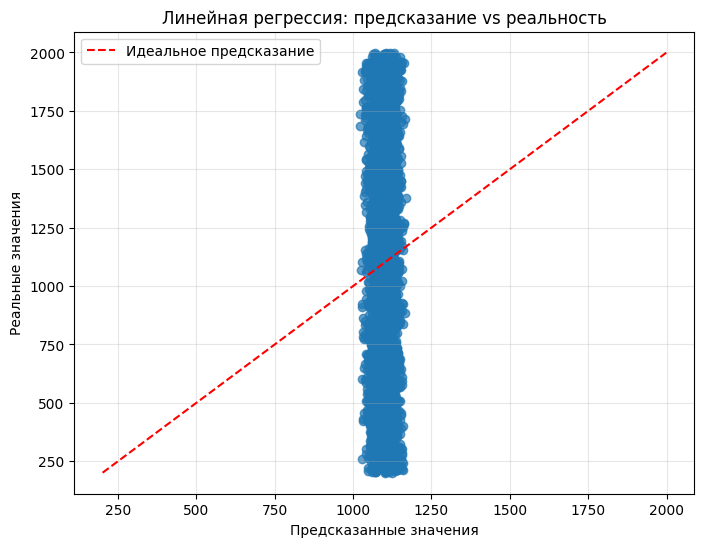


 МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): -0.0009
MSE: 270993.46
RMSE: 520.57
MAE: 450.67
Типы данных в df_reg_data:
Brand                       int64
Capacity                  float64
Energy Rating               int64
Type                        int64
Color                       int64
Material                    int64
Warranty Period           float64
Country of Manufacture      int64
has_Smart_Connectivity      int64
has_Water_Dispenser         int64
has_Ice_Dispenser           int64
dtype: object

Столбцы с типом object:
[]


In [7]:
#Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_lin, target_test_reg)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

#Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lin, target_test_reg, alpha=0.7)

#Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_lin.min(), target_test_reg.min())
max_val = max(predicted_lin.max(), target_test_reg.max())

#Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Линейная регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Дополнительные метрики качества
print("\n" + "=" * 50)
print(" МЕТРИКИ КАЧЕСТВА")

r2 = model_lin.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_lin)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_lin)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Проверяем, есть ли ещё текстовые столбцы
print("Типы данных в df_reg_data:")
print(df_reg_data.dtypes)
print("\nСтолбцы с типом object:")
print(df_reg_data.select_dtypes(include=['object']).columns.tolist())

### Полиномиальная регрессия

In [8]:
polynomial_regression = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression(fit_intercept=False))])
model_pol = polynomial_regression.fit(data_train_reg, target_train_reg)
predicted_pol = model_pol.predict(data_test_reg)

Визуализация результатов

Сравнение предсказаний с реальными значениями:
   Предсказано (полином. degree=3)  На самом деле
0                      1115.720369         1082.0
1                      1076.321907          765.0
2                      1158.564773         1523.0
3                       925.243553          867.0
4                      1062.429851         1551.0
5                      1045.734044         1885.0
6                      1381.544332          922.0
7                      1067.675969          527.0
8                      1020.799365         1409.0
9                       995.623151          468.0

Статистика по предсказаниям и реальным значениям:
       Предсказано (полином. degree=3)  На самом деле
count                      2830.000000    2830.000000
mean                       1102.392799    1103.832862
std                         105.324744     520.434511
min                         652.838767     201.000000
25%                        1036.640441     653.250000
50%                        1

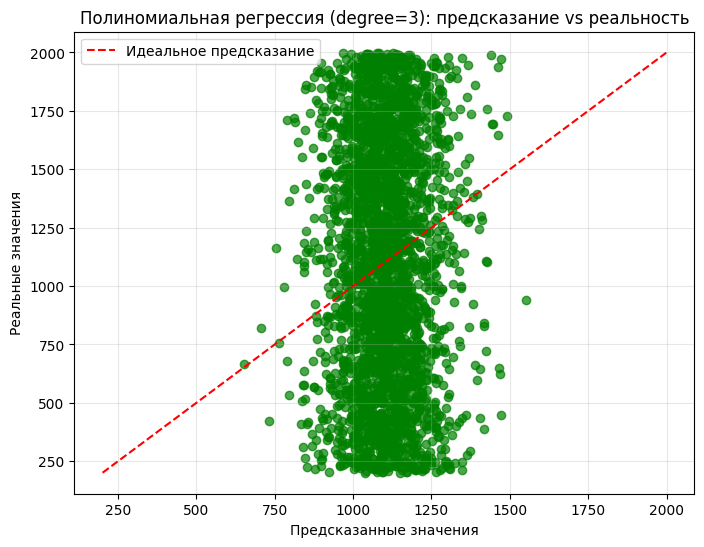


МЕТРИКИ КАЧЕСТВА
R² (коэффициент детерминации): -0.0456
MSE: 283108.77
RMSE: 532.08
MAE: 458.23


In [9]:
#Построим таблицу сравнения предсказаний с реальными значениями
results_table = pd.DataFrame(list(zip(predicted_pol, target_test_reg)))
results_table.columns = ['Предсказано (полином. degree=3)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())


#Построим график: предсказанные vs реальные значения
plt.figure(figsize=(8, 6))
plt.scatter(predicted_pol, target_test_reg, alpha=0.7, color='green')

#Определяем границы красной линии (линия идеального предсказания)
#Берём min и max от объединённых значений предсказанных и реальных
min_val = min(predicted_pol.min(), target_test_reg.min())
max_val = max(predicted_pol.max(), target_test_reg.max())

#Строим красную линию y = x от min_val до max_val
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Полиномиальная регрессия (degree=3): предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Метрики качества
print("\n" + "=" * 50)
print("МЕТРИКИ КАЧЕСТВА")
r2 = model_pol.score(data_test_reg, target_test_reg)
mse = metrics.mean_squared_error(target_test_reg, predicted_pol)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(target_test_reg, predicted_pol)

print(f"R² (коэффициент детерминации): {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


### Дополнительные методы

LASSO РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Lasso)  На самом деле
0          1097.769246         1082.0
1          1084.961840          765.0
2          1101.577812         1523.0
3          1082.520659          867.0
4          1110.387509         1551.0
5          1100.888594         1885.0
6          1152.592354          922.0
7          1067.459187          527.0
8          1088.919104         1409.0
9          1113.053848          468.0

Статистика:
       Предсказано (Lasso)  На самом деле
count          2830.000000    2830.000000
mean           1100.180903    1103.832862
std              25.072517     520.434511
min            1028.543997     201.000000
25%            1082.587308     653.250000
50%            1102.414872    1110.000000
75%            1119.248300    1557.750000
max            1159.395569    1999.000000


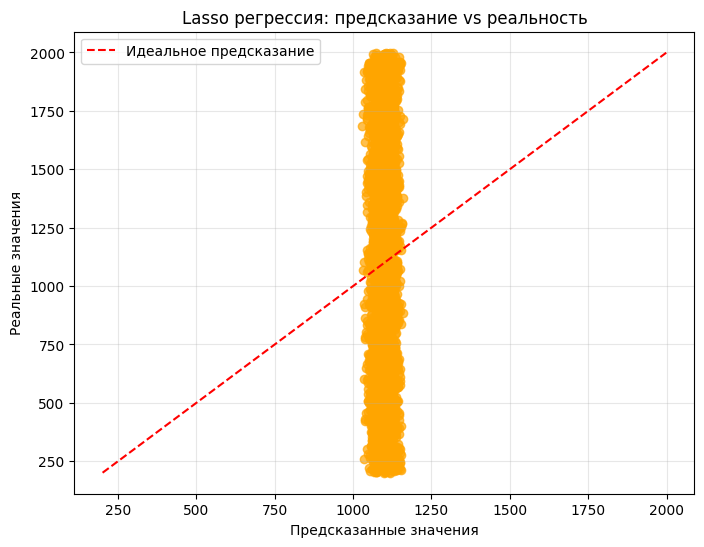


МЕТРИКИ КАЧЕСТВА
R²: -0.0005
MSE: 270899.21
RMSE: 520.48
MAE: 450.64


In [10]:
#Lasso регрессия (L1-регуляризация)
print("=" * 40)
print("LASSO РЕГРЕССИЯ")

lin_lasso = Lasso(alpha=1.0)
model_lasso = lin_lasso.fit(data_train_reg, target_train_reg)
predicted_lasso = model_lasso.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_lasso, target_test_reg)))
results_table.columns = ['Предсказано (Lasso)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_lasso, target_test_reg, alpha=0.7, color='orange')

min_val = min(predicted_lasso.min(), target_test_reg.min())
max_val = max(predicted_lasso.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Lasso регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_lasso):.2f}")

RIDGE РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (Ridge)  На самом деле
0          1095.121474         1082.0
1          1082.270243          765.0
2          1101.912944         1523.0
3          1079.000590          867.0
4          1110.731964         1551.0
5          1103.937039         1885.0
6          1158.504301          922.0
7          1065.440113          527.0
8          1089.495305         1409.0
9          1117.813792          468.0

Статистика:
       Предсказано (Ridge)  На самом деле
count          2830.000000    2830.000000
mean           1100.268211    1103.832862
std              27.816097     520.434511
min            1020.606426     201.000000
25%            1080.425252     653.250000
50%            1102.471449    1110.000000
75%            1121.341790    1557.750000
max            1167.651792    1999.000000


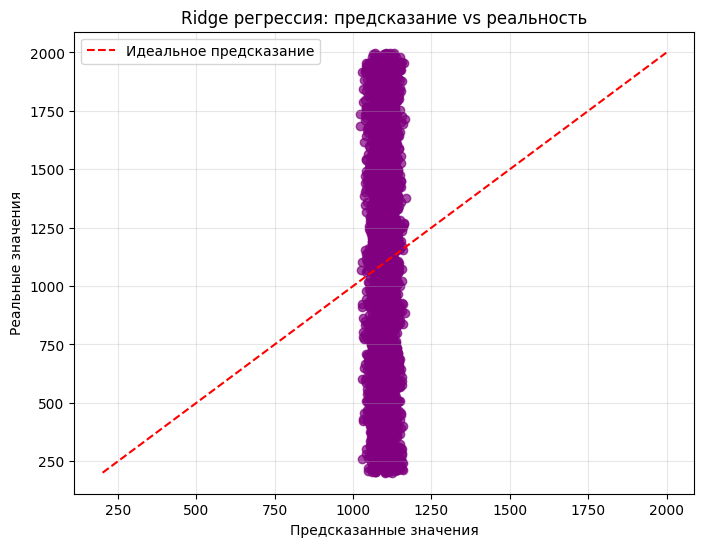


МЕТРИКИ КАЧЕСТВА
R²: -0.0009
MSE: 270993.24
RMSE: 520.57
MAE: 450.67


In [11]:
#Ridge регрессия (L2-регуляризация)
print("=" * 40)
print("RIDGE РЕГРЕССИЯ")

lin_ridge = Ridge(alpha=1.0)
model_ridge = lin_ridge.fit(data_train_reg, target_train_reg)
predicted_ridge = model_ridge.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_ridge, target_test_reg)))
results_table.columns = ['Предсказано (Ridge)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_ridge, target_test_reg, alpha=0.7, color='purple')

min_val = min(predicted_ridge.min(), target_test_reg.min())
max_val = max(predicted_ridge.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Ridge регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_ridge):.2f}")

ELASTIC NET РЕГРЕССИЯ
Сравнение предсказаний с реальными значениями:
   Предсказано (ElasticNet)  На самом деле
0               1096.476047         1082.0
1               1083.921044          765.0
2               1098.154408         1523.0
3               1095.911961          867.0
4               1103.768611         1551.0
5               1092.828799         1885.0
6               1138.839273          922.0
7               1080.676930          527.0
8               1084.001694         1409.0
9               1099.655477          468.0

Статистика:
       Предсказано (ElasticNet)  На самом деле
count               2830.000000    2830.000000
mean                1099.635235    1103.832862
std                   16.451412     520.434511
min                 1050.635983     201.000000
25%                 1087.766292     653.250000
50%                 1099.811316    1110.000000
75%                 1111.743652    1557.750000
max                 1142.615742    1999.000000


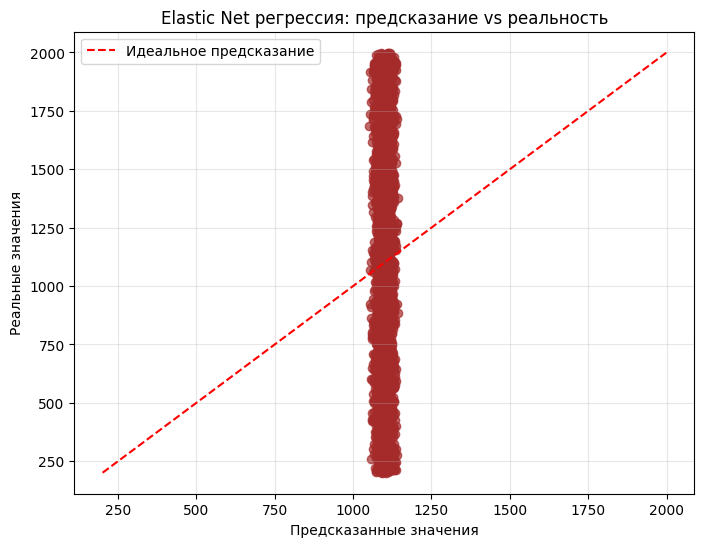


МЕТРИКИ КАЧЕСТВА
R²: -0.0001
MSE: 270789.00
RMSE: 520.37
MAE: 450.71


In [12]:
#Elastic Net регрессия (комбинация L1 и L2)
print("=" * 40)
print("ELASTIC NET РЕГРЕССИЯ")


lin_en = ElasticNet(alpha=1.0, l1_ratio=0.5)
model_en = lin_en.fit(data_train_reg, target_train_reg)
predicted_en = model_en.predict(data_test_reg)

#Таблица сравнения
results_table = pd.DataFrame(list(zip(predicted_en, target_test_reg)))
results_table.columns = ['Предсказано (ElasticNet)', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика:")
print(results_table.describe())

#График
plt.figure(figsize=(8, 6))
plt.scatter(predicted_en, target_test_reg, alpha=0.7, color='brown')

min_val = min(predicted_en.min(), target_test_reg.min())
max_val = max(predicted_en.max(), target_test_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')

plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.title('Elastic Net регрессия: предсказание vs реальность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Оценка качества (расширенная)
print("\n" + "=" * 40)
print("МЕТРИКИ КАЧЕСТВА")
print(f"R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")
print(f"MAE: {metrics.mean_absolute_error(target_test_reg, predicted_en):.2f}")

In [13]:
#Сводная таблица сравнения всех моделей
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ")

#Словарь с моделями и их названиями
models = {
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Polynomial (degree=3)': Pipeline([('poly', PolynomialFeatures(degree=3)), 
                                         ('linear', LinearRegression(fit_intercept=False))])
}

#Сбор результатов
results_summary = []
for name, model in models.items():
    model.fit(data_train_reg, target_train_reg)
    predicted = model.predict(data_test_reg)
    r2 = model.score(data_test_reg, target_test_reg)
    mse = metrics.mean_squared_error(target_test_reg, predicted)
    rmse = np.sqrt(mse)
    mae = metrics.mean_absolute_error(target_test_reg, predicted)
    results_summary.append({
        'Модель': name,
        'R²': round(r2, 4),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })

#Вывод сводной таблицы
summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))

#Определяем лучшую модель по R²
best_model_r2 = summary_df.loc[summary_df['R²'].idxmax(), 'Модель']
best_model_mse = summary_df.loc[summary_df['MSE'].idxmin(), 'Модель']
best_model_rmse = summary_df.loc[summary_df['RMSE'].idxmin(), 'Модель']

print(f"\n🏆 Лучшая модель по R²: {best_model_r2}")
print(f"🏆 Лучшая модель по MSE: {best_model_mse}")
print(f"🏆 Лучшая модель по RMSE: {best_model_rmse}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ РЕГРЕССИИ
               Модель      R²       MSE   RMSE    MAE
     LinearRegression -0.0009 270993.46 520.57 450.67
                Lasso -0.0005 270899.21 520.48 450.64
                Ridge -0.0009 270993.24 520.57 450.67
           ElasticNet -0.0001 270789.00 520.37 450.71
Polynomial (degree=3) -0.0456 283108.77 532.08 458.23

🏆 Лучшая модель по R²: ElasticNet
🏆 Лучшая модель по MSE: ElasticNet
🏆 Лучшая модель по RMSE: ElasticNet


### Метрики качества

In [14]:
#Для каждого из использованных методов вывести метрики: r2, mse, rmse

print("=" * 40)
print("СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ")

#1.Линейная регрессия
print("\n1. Линейная регрессия")
print(f"   R²: {model_lin.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lin):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lin)):.2f}")

#2.Полиномиальная регрессия (degree=3)
print("\n2. Полиномиальная регрессия (degree=3)")
print(f"   R²: {model_pol.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_pol):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_pol)):.2f}")

#3.Lasso регрессия
print("\n3. Lasso регрессия")
print(f"   R²: {model_lasso.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_lasso):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_lasso)):.2f}")

#4.Ridge регрессия
print("\n4. Ridge регрессия")
print(f"   R²: {model_ridge.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_ridge):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_ridge)):.2f}")

#5.Elastic Net регрессия
print("\n5. Elastic Net регрессия")
print(f"   R²: {model_en.score(data_test_reg, target_test_reg):.4f}")
print(f"   MSE: {metrics.mean_squared_error(target_test_reg, predicted_en):.2f}")
print(f"   RMSE: {np.sqrt(metrics.mean_squared_error(target_test_reg, predicted_en)):.2f}")

print("\n" + "=" * 40)

#Определяем лучшую модель по R²
models_r2 = {
    'LinearRegression': model_lin.score(data_test_reg, target_test_reg),
    'Polynomial': model_pol.score(data_test_reg, target_test_reg),
    'Lasso': model_lasso.score(data_test_reg, target_test_reg),
    'Ridge': model_ridge.score(data_test_reg, target_test_reg),
    'ElasticNet': model_en.score(data_test_reg, target_test_reg)
}
best_model = max(models_r2, key=models_r2.get)
print(f"\n🏆 Лучшая модель по R²: {best_model} (R² = {models_r2[best_model]:.4f})")

СВОДКА МЕТРИК КАЧЕСТВА МОДЕЛЕЙ РЕГРЕССИИ

1. Линейная регрессия
   R²: -0.0009
   MSE: 270993.46
   RMSE: 520.57

2. Полиномиальная регрессия (degree=3)
   R²: -0.0456
   MSE: 283108.77
   RMSE: 532.08

3. Lasso регрессия
   R²: -0.0005
   MSE: 270899.21
   RMSE: 520.48

4. Ridge регрессия
   R²: -0.0009
   MSE: 270993.24
   RMSE: 520.57

5. Elastic Net регрессия
   R²: -0.0001
   MSE: 270789.00
   RMSE: 520.37


🏆 Лучшая модель по R²: ElasticNet (R² = -0.0001)


### Вывод по результатам прогнозирования

В этом поле опишите вывод - какая модель лучше, почему, возможно ли вообще прогнозирование 

In [25]:
# ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИОННОГО АНАЛИЗА

print("=" * 60)
print("ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИИ")
print("=" * 60)

print("""
1. Какая модель лучше?

Лучше всего показала себя модель Elastic Net:
- R² = -0.0001 (наименее отрицательный среди всех моделей)
- MSE = 270789.00 (наименьшая среднеквадратичная ошибка)
- RMSE = 520.37 (наименьшая ошибка предсказания)

Lasso показала близкий результат (R² = -0.0005, RMSE = 520.48).

Полиномиальная регрессия оказалась хуже всех (R² = -0.0456, RMSE = 532.08).

2. Возможно ли прогнозирование?

НЕТ, прогнозировать цену холодильников (Price) по имеющимся признакам 
НЕ ПОЛУЧАЕТСЯ качественно.

Обоснование:
- R² отрицательный (от -0.0001 до -0.0456) — модель предсказывает хуже,
  чем просто средняя цена
- Ошибка RMSE ≈ 520 единиц — это около 47% от средней цены (1100)
- Модель предсказывает цены в узком диапазоне (1020–1170), 
  в то время как реальные цены варьируются от 200 до 2000

3. Почему так получилось?

- Признаки (Capacity, Energy Rating, Type, Features) слабо коррелируют с ценой
- В данных большой разброс цен при похожих характеристиках
- Возможно, нужны дополнительные признаки (например, объём, размер, класс)

4. Итог

Elastic Net показала лучший (но всё ещё отрицательный) результат.
Прогнозирование цены холодильников по имеющимся данным невозможно с 
приемлемой точностью. Рекомендуется:
- Добавить больше значимых признаков
- Использовать нелинейные модели (Random Forest, Gradient Boosting)
- Либо сосредоточиться на задаче классификации (бренды)
""")

print("=" * 60)

ВЫВОД ПО РЕЗУЛЬТАТАМ РЕГРЕССИИ

1. Какая модель лучше?

Лучше всего показала себя модель Elastic Net:
- R² = -0.0001 (наименее отрицательный среди всех моделей)
- MSE = 270789.00 (наименьшая среднеквадратичная ошибка)
- RMSE = 520.37 (наименьшая ошибка предсказания)

Lasso показала близкий результат (R² = -0.0005, RMSE = 520.48).

Полиномиальная регрессия оказалась хуже всех (R² = -0.0456, RMSE = 532.08).

2. Возможно ли прогнозирование?

НЕТ, прогнозировать цену холодильников (Price) по имеющимся признакам 
НЕ ПОЛУЧАЕТСЯ качественно.

Обоснование:
- R² отрицательный (от -0.0001 до -0.0456) — модель предсказывает хуже,
  чем просто средняя цена
- Ошибка RMSE ≈ 520 единиц — это около 47% от средней цены (1100)
- Модель предсказывает цены в узком диапазоне (1020–1170), 
  в то время как реальные цены варьируются от 200 до 2000

3. Почему так получилось?

- Признаки (Capacity, Energy Rating, Type, Features) слабо коррелируют с ценой
- В данных большой разброс цен при похожих характеристик

## Часть 3 Классификация

### Логистическая регрессия

In [26]:
import warnings
warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

print(f"\nТочность: {model_log.score(data_test_cl, target_test_cl):.4f}")

#Включаем предупреждения обратно
warnings.filterwarnings('default')


Точность: 0.0947


Результаты прогнозирования

In [27]:
#Таблица результатов логистической регрессии
results_table = pd.DataFrame(list(zip(predicted_log, target_test_cl)))
results_table.columns = ['Предсказано', 'На самом деле']
print("Сравнение предсказаний с реальными значениями:")
print(results_table.head(10))
print("\nСтатистика по предсказаниям и реальным значениям:")
print(results_table.describe())

#Точность модели
print(f"\nТочность модели: {model_log.score(data_test_cl, target_test_cl):.4f}")

Сравнение предсказаний с реальными значениями:
   Предсказано  На самом деле
0            2              4
1            2              6
2            1              9
3            5              1
4            1              6
5            7              4
6            4              8
7            7              4
8            2              9
9            1              7

Статистика по предсказаниям и реальным значениям:
       Предсказано  На самом деле
count  2830.000000    2830.000000
mean      3.984452       4.496113
std       2.409575       2.913593
min       0.000000       0.000000
25%       2.000000       2.000000
50%       4.000000       4.000000
75%       6.000000       7.000000
max       9.000000      10.000000

Точность модели: 0.0947


Матрица несоответствий

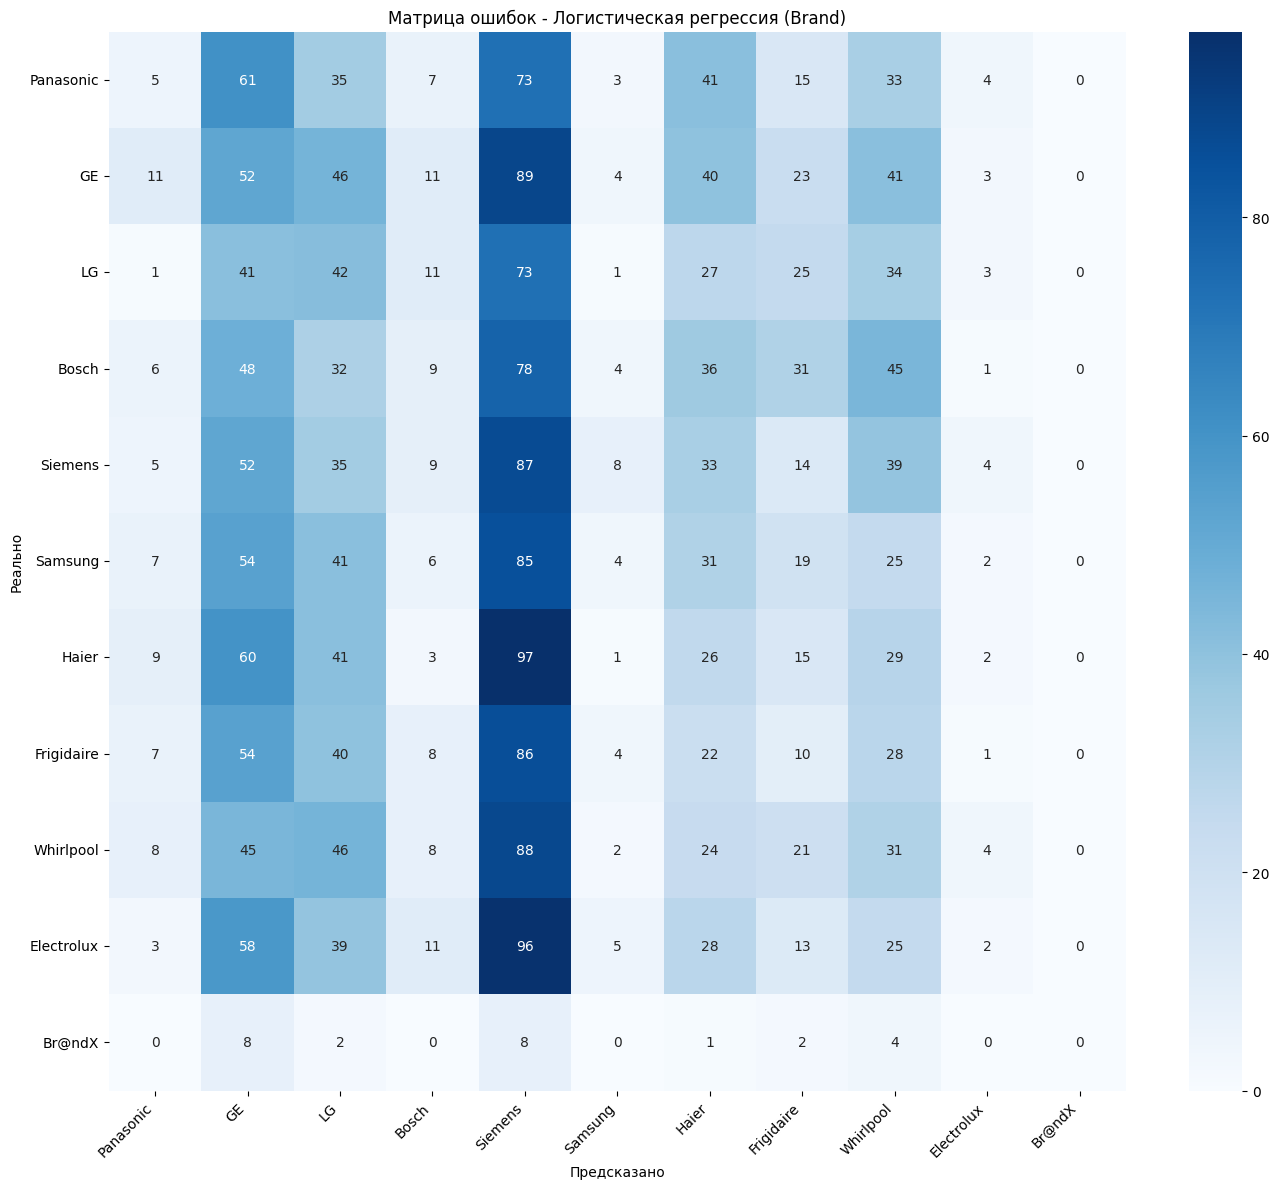

In [32]:
# Названия классов (бренды из твоего датасета)
# Порядок должен соответствовать числам: 0,1,2,3,4,5,6,7,8,9,10
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

# Все возможные классы (от 0 до 10)
all_classes = list(range(11))

confusion_scores = confusion_matrix(target_test_cl, predicted_log, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues').plot()
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Логистическая регрессия (Brand)')
plt.tight_layout()
plt.show()

### Метрики

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Brand)
Точность (accuracy): 0.0947
F1 - мера: 0.0752


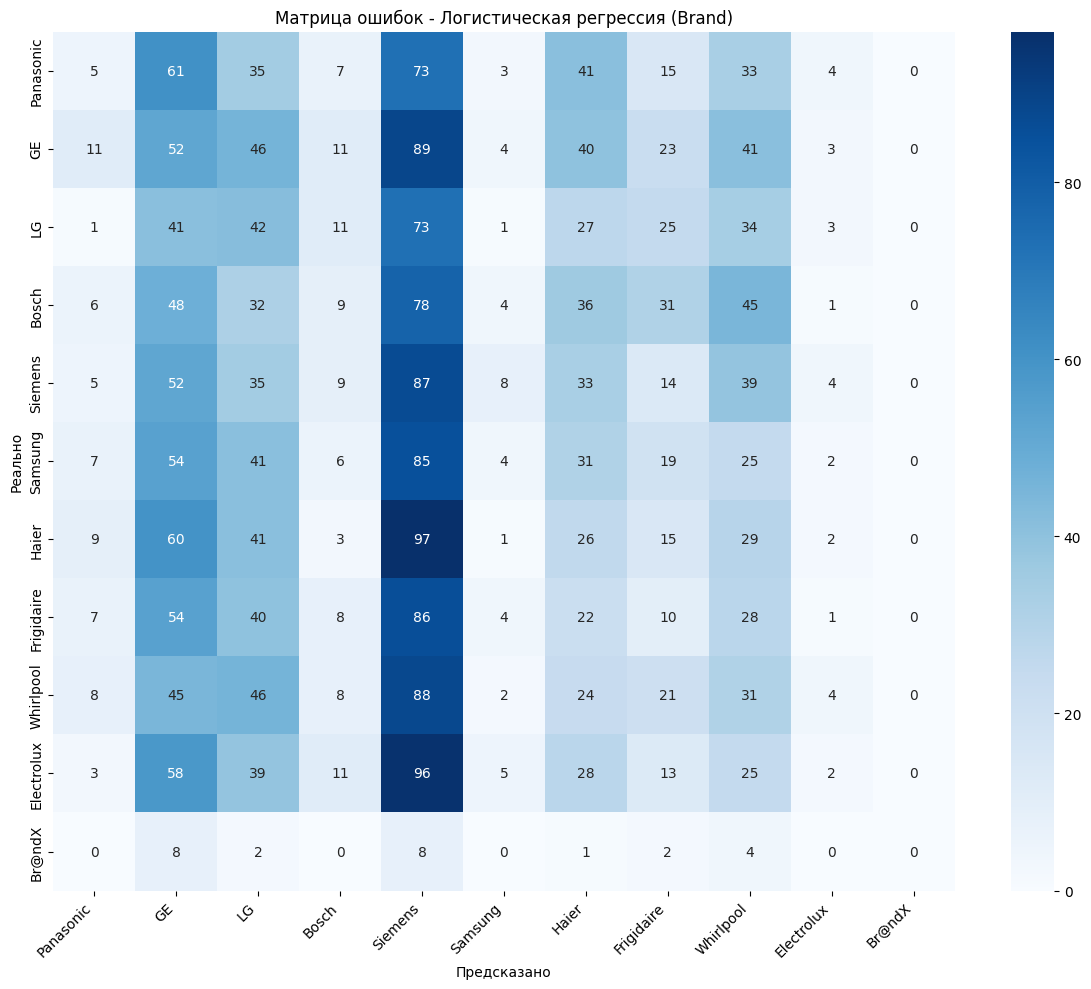


Отчёт по классификации:
              precision    recall  f1-score   support

           0       0.08      0.02      0.03       277
           1       0.10      0.16      0.12       320
           2       0.11      0.16      0.13       258
           3       0.11      0.03      0.05       290
           4       0.10      0.30      0.15       286
           5       0.11      0.01      0.03       274
           6       0.08      0.09      0.09       283
           7       0.05      0.04      0.04       260
           8       0.09      0.11      0.10       277
           9       0.08      0.01      0.01       280
          10       0.00      0.00      0.00        25

    accuracy                           0.09      2830
   macro avg       0.08      0.09      0.07      2830
weighted avg       0.09      0.09      0.08      2830



In [33]:
import warnings

# ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
print("=" * 40)
print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Brand)")

warnings.filterwarnings('ignore')

logistic_regression = LogisticRegression(solver='newton-cg', max_iter=2000)
model_log = logistic_regression.fit(data_train_cl, target_train_cl)
predicted_log = model_log.predict(data_test_cl)

warnings.filterwarnings('default')

# Точность
print(f"Точность (accuracy): {model_log.score(data_test_cl, target_test_cl):.4f}")

# F1 - мера
print(f"F1 - мера: {f1_score(target_test_cl, predicted_log, average='weighted'):.4f}")

# Матрица ошибок (бренды)
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

# Все классы от 0 до 10
all_classes = list(range(11))

confusion_scores = confusion_matrix(target_test_cl, predicted_log, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, 
                            columns=class_names,
                            index=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues').plot()
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Логистическая регрессия (Brand)')
plt.tight_layout()
plt.show()

print("\nОтчёт по классификации:")
print(classification_report(target_test_cl, predicted_log, zero_division=0))

In [34]:
# Количество конкретных брендов в train
count_panasonic = (target_train_cl == 0).sum()
count_ge = (target_train_cl == 1).sum()
count_lg = (target_train_cl == 2).sum()
count_bosch = (target_train_cl == 3).sum()
count_siemens = (target_train_cl == 4).sum()
count_samsung = (target_train_cl == 5).sum()
count_haier = (target_train_cl == 6).sum()
count_frigidaire = (target_train_cl == 7).sum()
count_whirlpool = (target_train_cl == 8).sum()
count_electrolux = (target_train_cl == 9).sum()
count_brx = (target_train_cl == 10).sum()

print(f"Бренд Panasonic (0) в train: {count_panasonic} записей")
print(f"Бренд GE (1) в train: {count_ge} записей")
print(f"Бренд LG (2) в train: {count_lg} записей")
print(f"Бренд Bosch (3) в train: {count_bosch} записей")
print(f"Бренд Siemens (4) в train: {count_siemens} записей")
print(f"Бренд Samsung (5) в train: {count_samsung} записей")
print(f"Бренд Haier (6) в train: {count_haier} записей")
print(f"Бренд Frigidaire (7) в train: {count_frigidaire} записей")
print(f"Бренд Whirlpool (8) в train: {count_whirlpool} записей")
print(f"Бренд Electrolux (9) в train: {count_electrolux} записей")
print(f"Бренд Br@ndX (10) в train: {count_brx} записей")

Бренд Panasonic (0) в train: 623 записей
Бренд GE (1) в train: 667 записей
Бренд LG (2) в train: 644 записей
Бренд Bosch (3) в train: 634 записей
Бренд Siemens (4) в train: 708 записей
Бренд Samsung (5) в train: 638 записей
Бренд Haier (6) в train: 693 записей
Бренд Frigidaire (7) в train: 668 записей
Бренд Whirlpool (8) в train: 651 записей
Бренд Electrolux (9) в train: 620 записей
Бренд Br@ndX (10) в train: 56 записей


SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)
Точность (accuracy): 0.0954

Отчёт по классификации SVC:
              precision    recall  f1-score   support

           0       0.10      0.05      0.07       277
           1       0.08      0.08      0.08       320
           2       0.12      0.12      0.12       258
           3       0.06      0.05      0.06       290
           4       0.11      0.23      0.15       286
           5       0.09      0.05      0.06       274
           6       0.12      0.16      0.14       283
           7       0.11      0.11      0.11       260
           8       0.06      0.07      0.06       277
           9       0.08      0.04      0.06       280
          10       0.00      0.00      0.00        25

    accuracy                           0.10      2830
   macro avg       0.08      0.09      0.08      2830
weighted avg       0.09      0.10      0.09      2830



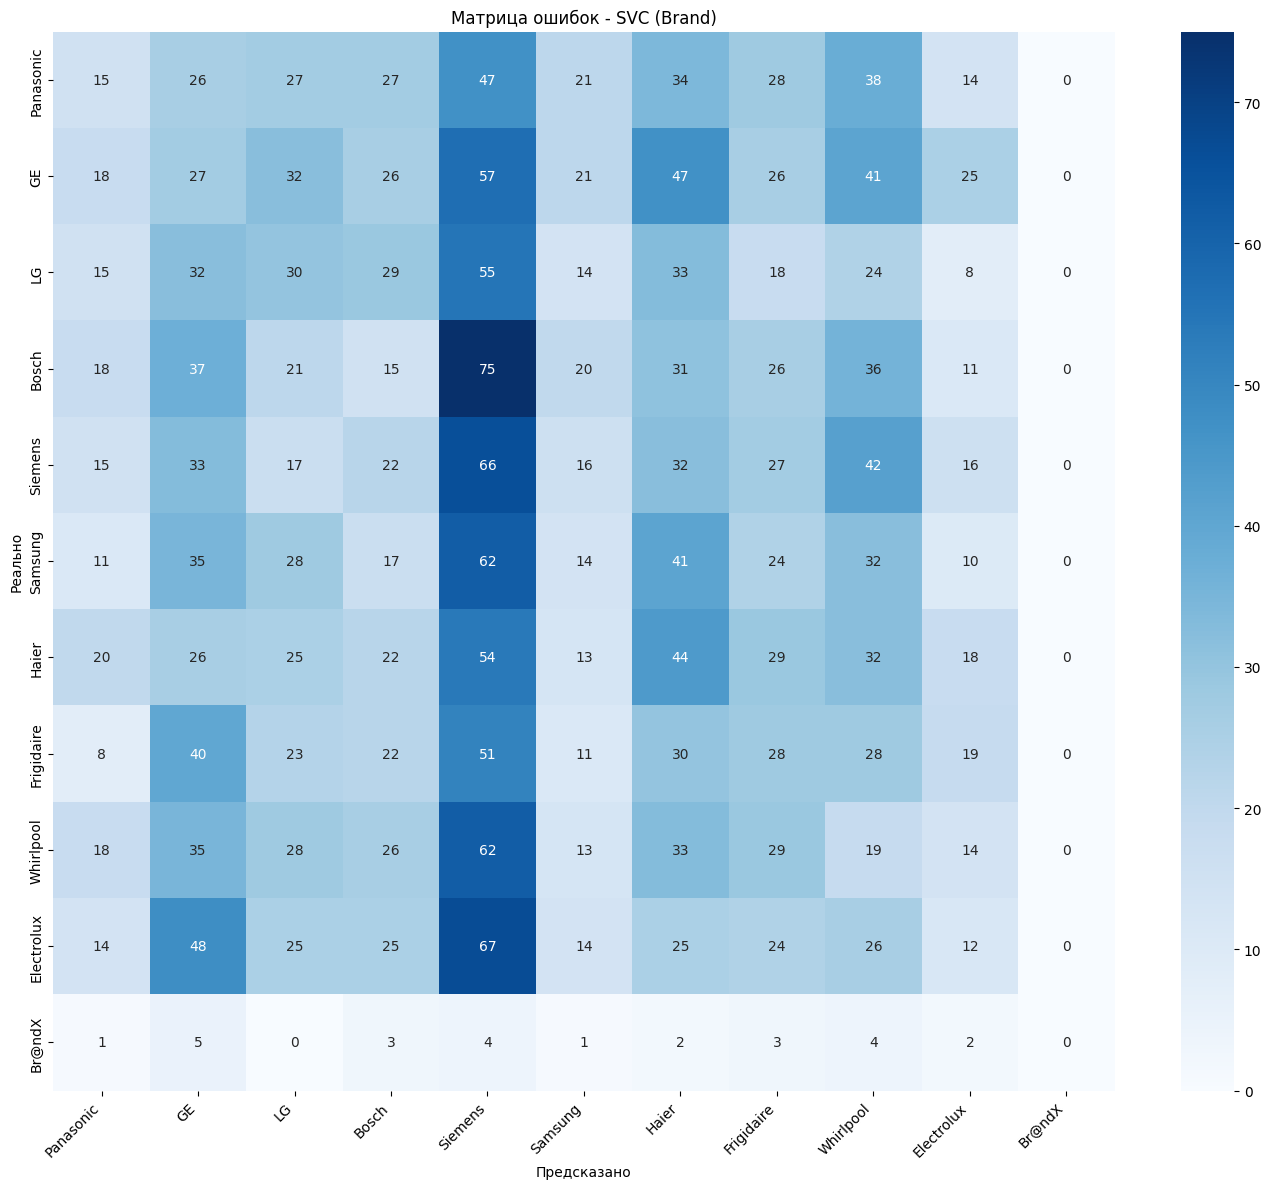

In [40]:
#SVC с нормализацией
SVC_pol = Pipeline([('Scale', StandardScaler()), ('SVC', SVC(gamma='auto'))])
model_svc = SVC_pol.fit(data_train_cl, target_train_cl)
predicted_svc = model_svc.predict(data_test_cl)

print("=" * 40)
print("SVC (МЕТОД ОПОРНЫХ ВЕКТОРОВ)")

print(f"Точность (accuracy): {model_svc.score(data_test_cl, target_test_cl):.4f}")

from sklearn.metrics import classification_report
print("\nОтчёт по классификации SVC:")
print(classification_report(target_test_cl, predicted_svc, zero_division=0))

# Матрица ошибок SVC
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

confusion_scores_svc = confusion_matrix(target_test_cl, predicted_svc, labels=range(11))
confusion_df_svc = pd.DataFrame(confusion_scores_svc, 
                                columns=class_names,
                                index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_svc, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - SVC (Brand)')
plt.tight_layout()
plt.show()

RANDOM FOREST (без ограничений)
Точность (accuracy): 0.0926


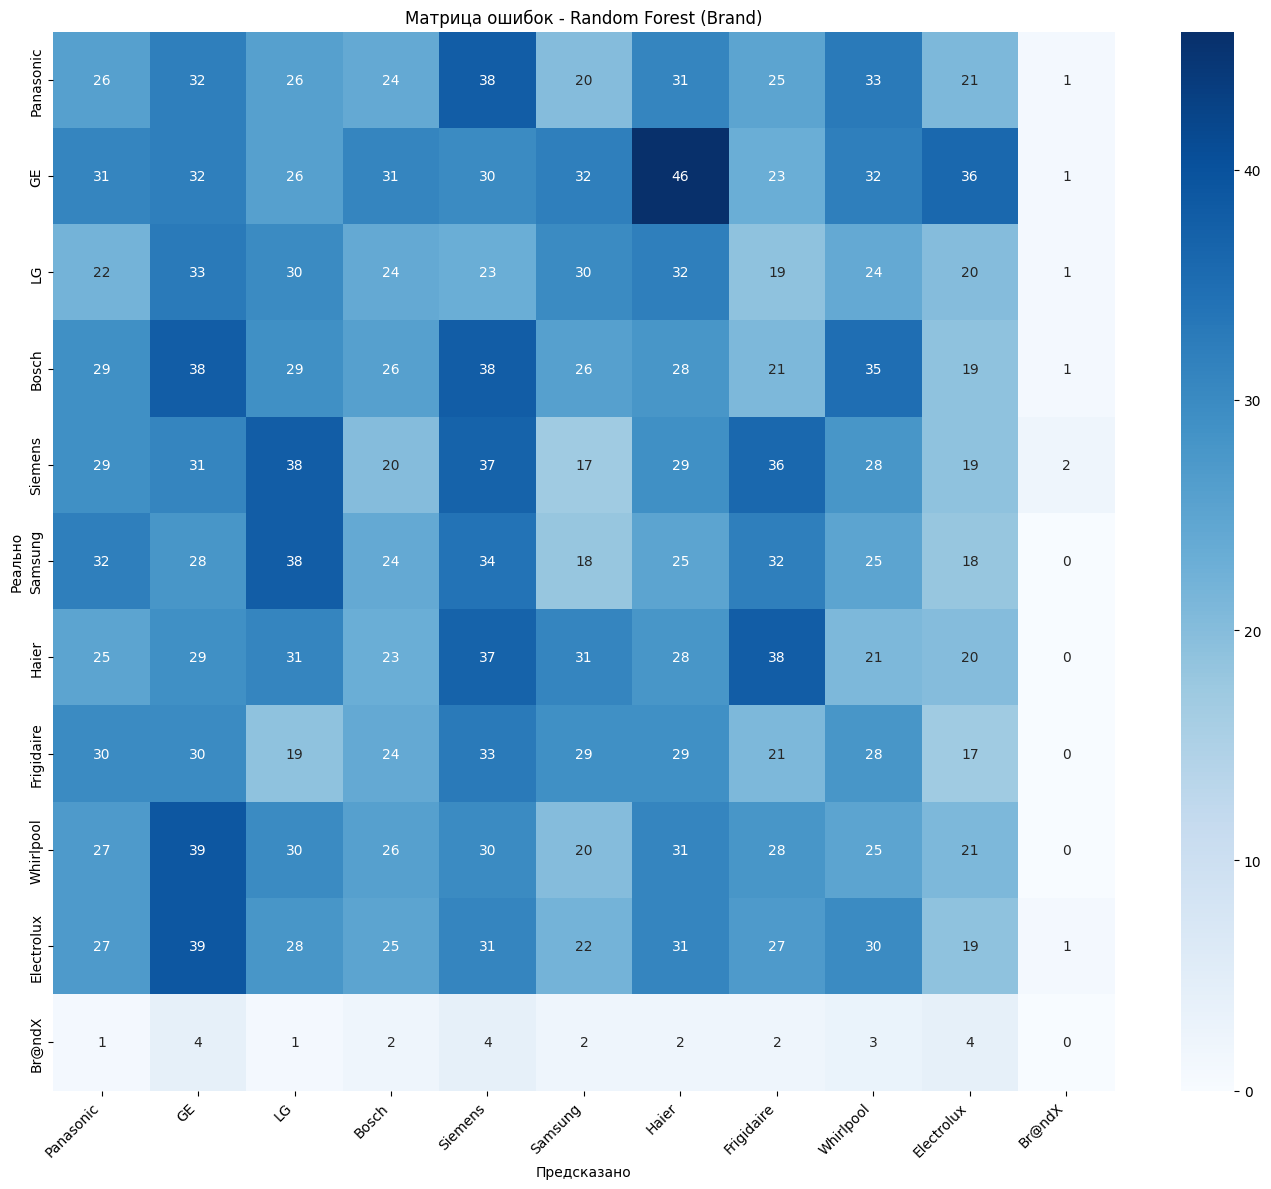

In [41]:
#Random Forest (без ограничения глубины)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf = random_forest.fit(data_train_cl, target_train_cl)
predicted_rf = model_rf.predict(data_test_cl)

print("=" * 40)
print("RANDOM FOREST (без ограничений)")

print(f"Точность (accuracy): {model_rf.score(data_test_cl, target_test_cl):.4f}")

# Матрица ошибок Random Forest
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

confusion_scores_rf = confusion_matrix(target_test_cl, predicted_rf, labels=range(11))
confusion_df_rf = pd.DataFrame(confusion_scores_rf, 
                               columns=class_names,
                               index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_rf, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Random Forest (Brand)')
plt.tight_layout()
plt.show()

RANDOM FOREST (max_depth=3)
Точность (accuracy): 0.1011

Отчёт по классификации Random Forest (max_depth=3):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       277
           1       0.10      0.07      0.08       320
           2       0.12      0.05      0.07       258
           3       0.09      0.01      0.02       290
           4       0.11      0.67      0.18       286
           5       0.14      0.00      0.01       274
           6       0.09      0.14      0.11       283
           7       0.09      0.05      0.06       260
           8       0.05      0.01      0.02       277
           9       0.17      0.00      0.01       280
          10       0.00      0.00      0.00        25

    accuracy                           0.10      2830
   macro avg       0.09      0.09      0.05      2830
weighted avg       0.09      0.10      0.06      2830



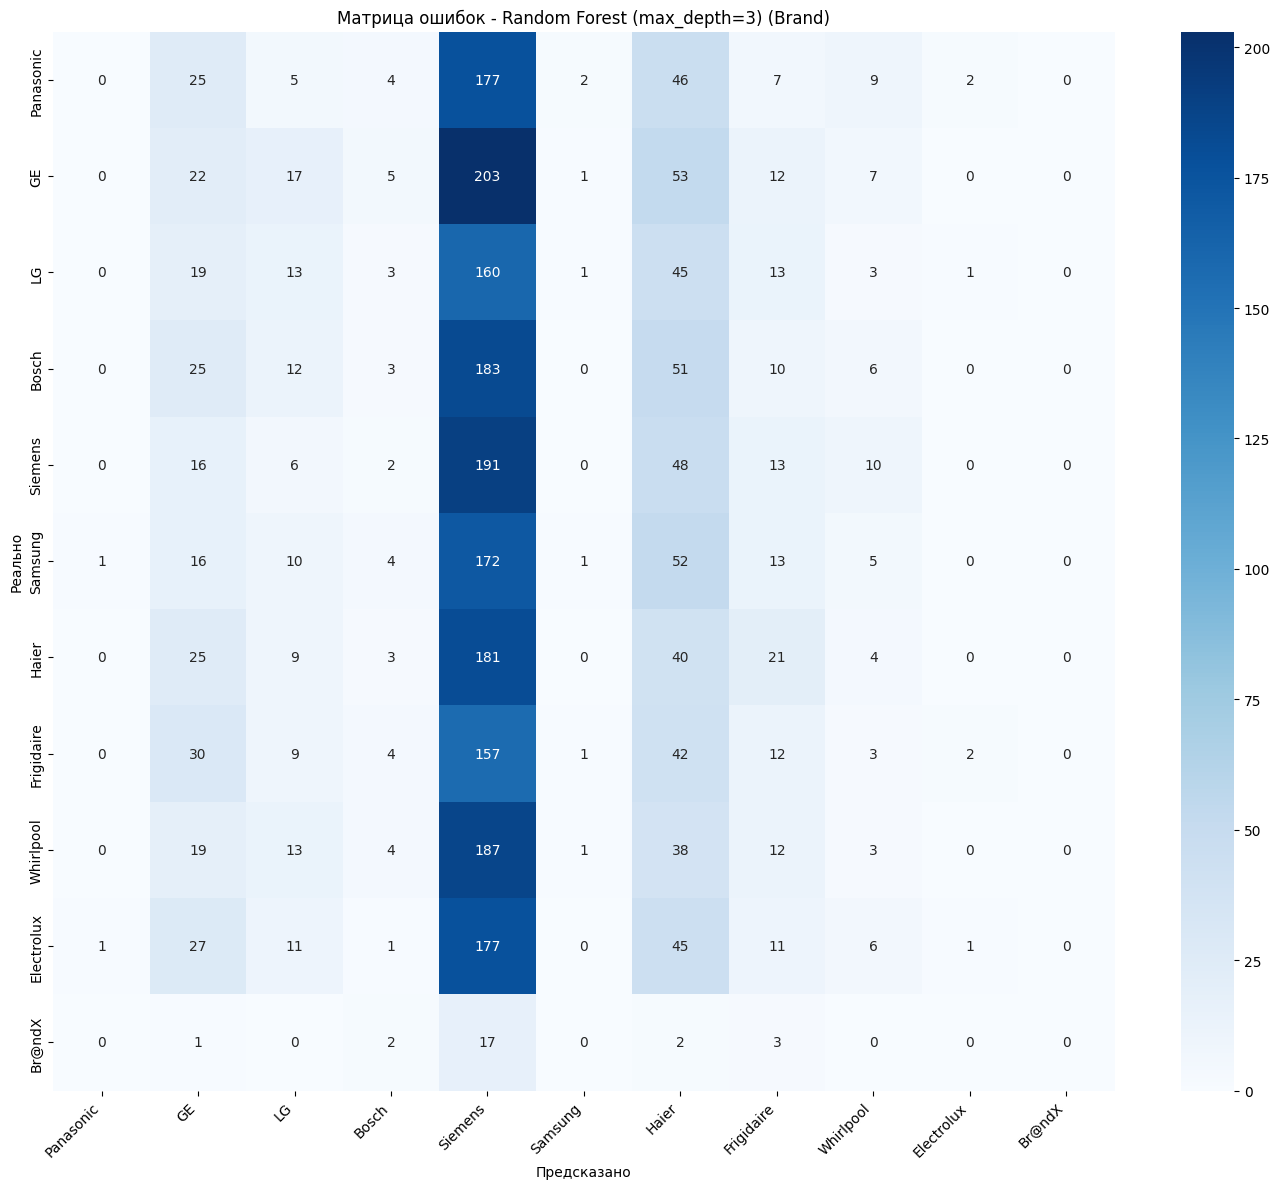

In [42]:
#Random Forest с ограничением глубины
from sklearn.ensemble import RandomForestClassifier

random_forest2 = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
model_rf2 = random_forest2.fit(data_train_cl, target_train_cl)
predicted_rf2 = model_rf2.predict(data_test_cl)

print("=" * 40)
print("RANDOM FOREST (max_depth=3)")

print(f"Точность (accuracy): {model_rf2.score(data_test_cl, target_test_cl):.4f}")

print("\nОтчёт по классификации Random Forest (max_depth=3):")
print(classification_report(target_test_cl, predicted_rf2, zero_division=0))

# Матрица ошибок Random Forest (max_depth=3)
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

confusion_scores_rf2 = confusion_matrix(target_test_cl, predicted_rf2, labels=range(11))
confusion_df_rf2 = pd.DataFrame(confusion_scores_rf2, 
                                columns=class_names,
                                index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df_rf2, annot=True, fmt='.0f', cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок - Random Forest (max_depth=3) (Brand)')
plt.tight_layout()
plt.show()

In [43]:
#Сводное сравнение
print("=" * 40)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ")

models_comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'SVC', 'Random Forest', 'Random Forest (max_depth=3)'],
    'Accuracy': [
        model_log.score(data_test_cl, target_test_cl),
        model_svc.score(data_test_cl, target_test_cl),
        model_rf.score(data_test_cl, target_test_cl),
        model_rf2.score(data_test_cl, target_test_cl)
    ]
})

print(models_comparison.round(4))

best_model = models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель']
print(f"\n🏆 Лучшая модель по Accuracy: {best_model}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ КЛАССИФИКАЦИИ
                        Модель  Accuracy
0          Logistic Regression    0.0947
1                          SVC    0.0954
2                Random Forest    0.0926
3  Random Forest (max_depth=3)    0.1011

🏆 Лучшая модель по Accuracy: Random Forest (max_depth=3)


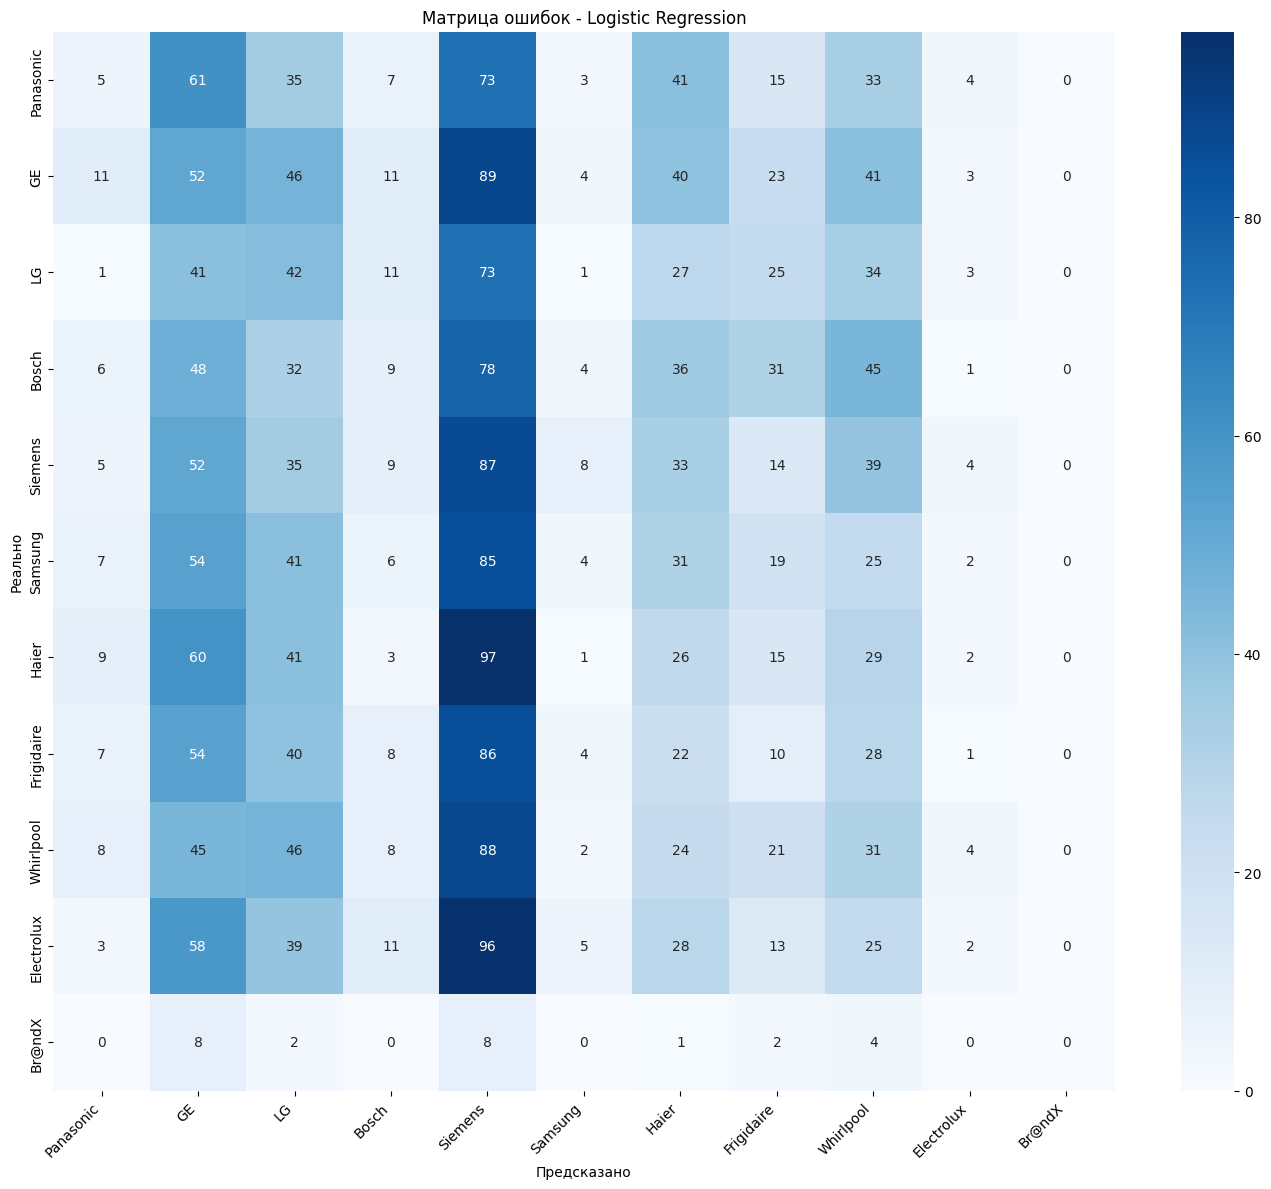

In [44]:
# Матрица ошибок для лучшей модели
if models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'Random Forest':
    best_predicted = predicted_rf
    best_name = 'Random Forest'
elif models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Модель'] == 'SVC':
    best_predicted = predicted_svc
    best_name = 'SVC'
else:
    best_predicted = predicted_log
    best_name = 'Logistic Regression'

# Названия брендов (0-10)
class_names = ['Panasonic', 'GE', 'LG', 'Bosch', 'Siemens', 
               'Samsung', 'Haier', 'Frigidaire', 'Whirlpool', 
               'Electrolux', 'Br@ndX']

# Все классы 0-10
all_classes = list(range(11))

confusion_scores = confusion_matrix(target_test_cl, best_predicted, labels=all_classes)
confusion_df = pd.DataFrame(confusion_scores, columns=class_names, index=class_names)

plt.figure(figsize=(14, 12))
sns.heatmap(confusion_df, annot=True, fmt='.0f', cmap='Blues')
plt.title(f'Матрица ошибок - {best_name}')
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Вывод по прогнозированию

In [45]:
print("=" * 60)
print("ВЫВОД ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ (BRAND)")
print("=" * 60)

print("""
1. Какая модель лучше?

Лучше всего показала себя модель Random Forest (max_depth=3):
- Accuracy = 10.11%

Остальные модели показали близкие результаты:
- SVC: 9.54%
- Logistic Regression: 9.47%
- Random Forest (без ограничений): 9.26%

2. Возможно ли прогнозирование бренда?

НЕТ, качественное прогнозирование бренда по имеющимся признакам НЕ ПОЛУЧАЕТСЯ.

Обоснование:
- Точность около 10% при случайном угадывании 9% (1 из 11 брендов)
- Модель практически не лучше случайного предположения
- F1-score для большинства классов близок к нулю
- Бренд Br@ndX (класс 10) не распознаётся совсем (precision = 0.00)

3. Почему так получилось?

- Признаки (Capacity, Energy Rating, Type, Features) плохо различают бренды
- Характеристики холодильников разных брендов слишком похожи
- Для определения бренда нужны другие признаки (дизайн, цена, маркетинг)

4. Итог

Ни одна из моделей не показала приемлемого качества.
Прогнозирование бренда по техническим характеристикам невозможно 
с удовлетворительной точностью. Рекомендуется:
- Использовать другие признаки (например, ценовой сегмент, страну бренда)
- Либо сосредоточиться на другой задаче (например, кластеризация)
""")

print("=" * 60)

ВЫВОД ПО РЕЗУЛЬТАТАМ КЛАССИФИКАЦИИ (BRAND)

1. Какая модель лучше?

Лучше всего показала себя модель Random Forest (max_depth=3):
- Accuracy = 10.11%

Остальные модели показали близкие результаты:
- SVC: 9.54%
- Logistic Regression: 9.47%
- Random Forest (без ограничений): 9.26%

2. Возможно ли прогнозирование бренда?

НЕТ, качественное прогнозирование бренда по имеющимся признакам НЕ ПОЛУЧАЕТСЯ.

Обоснование:
- Точность около 10% при случайном угадывании 9% (1 из 11 брендов)
- Модель практически не лучше случайного предположения
- F1-score для большинства классов близок к нулю
- Бренд Br@ndX (класс 10) не распознаётся совсем (precision = 0.00)

3. Почему так получилось?

- Признаки (Capacity, Energy Rating, Type, Features) плохо различают бренды
- Характеристики холодильников разных брендов слишком похожи
- Для определения бренда нужны другие признаки (дизайн, цена, маркетинг)

4. Итог

Ни одна из моделей не показала приемлемого качества.
Прогнозирование бренда по техническим характер